In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -q timm torchmetrics pycocotools

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 24.0 MB/s eta 0:00:00


In [3]:
import os
import glob
from pathlib import Path
from functools import partial

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from PIL import Image

from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import torchvision.transforms.functional as TF
from torchvision.models.detection.anchor_utils import AnchorGenerator
from torchvision.ops import box_iou, nms

import timm

from torchmetrics.detection.mean_ap import MeanAveragePrecision

In [4]:
# Пути к данным
train_images_dir = '/content/drive/MyDrive/МФТИ ML/Семестр 1/Итоговое задание/predictions/Segm/Unet/train'
train_labels_dir = "/content/drive/MyDrive/МФТИ ML/Семестр 1/Итоговое задание/YOLO_format/train/labels"

val_images_dir = '/content/drive/MyDrive/МФТИ ML/Семестр 1/Итоговое задание/predictions/Segm/Unet/test'
val_labels_dir = "/content/drive/MyDrive/МФТИ ML/Семестр 1/Итоговое задание/YOLO_format/val/labels"

In [5]:
# YOLO label: class_id x_center y_center width height, где все координаты нормализованы.
# Но в нашем детекторе для обучения удобнее использовать boxes в формате:x_min, y_min, width, height уже в пикселях изображения после resize.

class TextYoloDataset(Dataset):
    def __init__(
        self,
        images_dir,
        labels_dir,
        # input_size=(640, 640),
        input_size=(256, 256),
        image_ext=".jpg",
        normalize=True
    ):
        self.images_dir = Path(images_dir)
        self.labels_dir = Path(labels_dir)
        self.input_size = input_size
        self.image_ext = image_ext
        self.normalize = normalize

        self.image_paths = sorted(list(self.images_dir.glob(f"*{image_ext}")))

        if len(self.image_paths) == 0:
            raise RuntimeError(f"Не найдено изображений в папке: {self.images_dir}")

        self.mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        self.std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    def __len__(self):
        return len(self.image_paths)

    def _read_yolo_label(self, label_path, width, height):
        boxes = []
        labels = []

        if not label_path.exists():
            return (
                torch.zeros((0, 4), dtype=torch.float32),
                torch.zeros((0,), dtype=torch.long)
            )

        with open(label_path, "r") as f:
            lines = f.readlines()

        for line in lines:
            line = line.strip()

            if len(line) == 0:
                continue

            parts = line.split()

            if len(parts) != 5:
                continue

            class_id, x_center, y_center, box_w, box_h = parts

            # class_id = int(class_id)
            class_id = 0
            x_center = float(x_center)
            y_center = float(y_center)
            box_w = float(box_w)
            box_h = float(box_h)

            # YOLO normalized -> pixel coordinates
            x_center_px = x_center * width
            y_center_px = y_center * height
            box_w_px = box_w * width
            box_h_px = box_h * height

            x_min = x_center_px - box_w_px / 2
            y_min = y_center_px - box_h_px / 2

            # чуть защищаемся от плохих боксов
            x_min = max(0.0, min(x_min, width - 1))
            y_min = max(0.0, min(y_min, height - 1))
            box_w_px = max(1.0, min(box_w_px, width - x_min))
            box_h_px = max(1.0, min(box_h_px, height - y_min))

            boxes.append([x_min, y_min, box_w_px, box_h_px])
            labels.append(class_id)

        if len(boxes) == 0:
            boxes = torch.zeros((0, 4), dtype=torch.float32)
            labels = torch.zeros((0,), dtype=torch.long)
        else:
            boxes = torch.tensor(boxes, dtype=torch.float32)
            labels = torch.tensor(labels, dtype=torch.long)

        return boxes, labels

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]

        # img11.jpg -> img11.txt
        label_path = self.labels_dir / f"{image_path.stem}.txt"

        image = Image.open(image_path).convert("RGB")

        # resize изображения под фиксированный размер модели
        target_h, target_w = self.input_size
        image = image.resize((target_w, target_h))

        image = TF.to_tensor(image)

        if self.normalize:
            image = (image - self.mean) / self.std

        boxes, labels = self._read_yolo_label(
            label_path,
            width=target_w,
            height=target_h
        )

        target = {
            "boxes": boxes,      # [N, 4], формат xywh
            "labels": labels     # [N]
        }

        return image, target

In [6]:
# Collate function нужен, потому что на разных изображениях может быть разное количество текстовых областей,
# обычный DataLoader не сможет автоматически собрать targets в один tensor.

def detection_collate_fn(batch):
    images, targets = zip(*batch)
    images = torch.stack(images, dim=0)
    targets = list(targets)
    return images, targets

###Одноуровневый якорный однопроходный детектор текста на базе EfficientNet

In [7]:
# Backbone извлекает признаки из изображения. Здесь используется модель из timm
class Backbone(nn.Module):
    # Здесь я использую: out_indices=(-2,)
    # а не (-1,), потому что для детекции текста обычно полезна более детальная feature map.
    # Если поставить (-1,), feature map будет меньше, например 20 x 20 для картинки 640 x 640.
    # Если поставить (-2,), она может быть примерно 40 x 40, что лучше для небольших текстовых областей.
    def __init__(
        self,
        model_name="efficientnet_b0",
        out_indices=(-2,),
        pretrained=True,
        freeze=True
    ):
        super().__init__()

        try:
            self.backbone = timm.create_model(
                model_name,
                pretrained=pretrained,
                features_only=True,
                out_indices=out_indices
            )
        except Exception as e:
            print("Не удалось загрузить pretrained-веса. Используем pretrained=False.")
            print("Ошибка:", e)

            self.backbone = timm.create_model(
                model_name,
                pretrained=False,
                features_only=True,
                out_indices=out_indices
            )

        if freeze:
            for param in self.backbone.parameters():
                param.requires_grad = False

    def forward(self, x):
        return self.backbone(x)

In [8]:
class SimplifiedFPN(nn.Module):
    def __init__(self, in_channels, out_channels, use_activations=True):
        super().__init__()

        self.fpn_conv = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            padding=1
        )

        self.bn = nn.BatchNorm2d(out_channels)
        self.activation = nn.ReLU() if use_activations else nn.Identity()

    def forward(self, features):
        # features — список feature maps от timm
        # здесь мы используем только features[0]
        x = features[0]
        x = self.fpn_conv(x)
        x = self.bn(x)
        x = self.activation(x)
        return x

In [9]:
# Голова детектора предсказывает:
    # class logits;
    # bbox offsets;
    # objectness/confidence.

class DetectionHead(nn.Module):
    def __init__(self, in_channels, num_anchors, num_classes):
        super().__init__()

        self.conv = nn.Conv2d(
            in_channels,
            in_channels,
            kernel_size=3,
            padding=1
        )

        self.cls_head = nn.Conv2d(
            in_channels,
            num_anchors * num_classes,
            kernel_size=1
        )

        self.reg_head = nn.Conv2d(
            in_channels,
            num_anchors * 5,
            kernel_size=1
        )

        self.num_classes = num_classes
        self.num_anchors = num_anchors

    def forward(self, x):
        x = F.relu(self.conv(x))

        cls_logits = self.cls_head(x)
        bbox_preds = self.reg_head(x)

        return cls_logits, bbox_preds

In [10]:
class Detector(nn.Module):
    def __init__(
        self,
        backbone_model_name="efficientnet_b0",
        backbone_out_indices=(-2,),
        neck_n_channels=256,
        num_classes=1,
        anchor_sizes=(16, 32, 64, 128, 256),
        anchor_ratios=(0.25, 0.5, 1.0, 2.0, 4.0),
        input_size=(640, 640),
        pretrained_backbone=True,
        freeze_backbone=True
    ):
        super().__init__()

        self.num_classes = num_classes
        self.input_size = input_size

        self.backbone = Backbone(
            model_name=backbone_model_name,
            out_indices=backbone_out_indices,
            pretrained=pretrained_backbone,
            freeze=freeze_backbone
        )

        in_channels = self.backbone.backbone.feature_info.channels()[0]

        self.neck = SimplifiedFPN(
            in_channels=in_channels,
            out_channels=neck_n_channels
        )

        num_anchors = len(anchor_sizes) * len(anchor_ratios)

        self.head = DetectionHead(
            in_channels=neck_n_channels,
            num_anchors=num_anchors,
            num_classes=num_classes
        )

        # Anchor generator из torchvision
        anchor_generator = AnchorGenerator(
            sizes=(anchor_sizes,),
            aspect_ratios=(anchor_ratios,)
        )

        reduction = self.backbone.backbone.feature_info.reduction()[0]

        grid_h = input_size[0] // reduction
        grid_w = input_size[1] // reduction

        grid_sizes = [[grid_h, grid_w]]
        strides = [[reduction, reduction]]

        anchors = anchor_generator.grid_anchors(
            grid_sizes,
            strides
        )

        # list с одним tensor -> tensor
        anchors = torch.stack(anchors, dim=0)

        anchor_centers = (anchors[:, :, :2] + anchors[:, :, 2:]) / 2
        anchor_sizes_tensor = anchors[:, :, 2:] - anchors[:, :, :2]

        self.register_buffer("anchors", anchors)
        self.register_buffer("anchor_centers", anchor_centers)
        self.register_buffer("anchor_sizes", anchor_sizes_tensor)

    def forward(self, x):
        features = self.backbone(x)
        neck_features = self.neck(features)

        cls_logits, bbox_preds = self.head(neck_features)

        N = x.shape[0]

        # cls_logits:
        # [B, A * C, H, W] -> [B, H, W, A * C] -> [B, H * W * A, C]
        cls_logits = cls_logits.permute(0, 2, 3, 1).contiguous()
        cls_logits = cls_logits.view(N, -1, self.head.num_classes)

        # bbox_preds:
        # [B, A * 5, H, W] -> [B, H, W, A * 5] -> [B, H * W * A, 5]
        bbox_preds = bbox_preds.permute(0, 2, 3, 1).contiguous()
        bbox_preds = bbox_preds.view(N, -1, 5)

        bbox_offsets = bbox_preds[:, :, :4]
        confidence_logits = bbox_preds[:, :, 4]

        if self.training:
            return bbox_offsets, confidence_logits, cls_logits

        bboxes = self.decode_bboxes(bbox_offsets)

        confidence = torch.sigmoid(confidence_logits)

        # Для одного класса лучше sigmoid, а не softmax.
        # При num_classes=1 softmax всегда дал бы 1.
        cls_probs = torch.sigmoid(cls_logits)

        return bboxes, confidence, cls_probs

    def decode_bboxes(self, bbox_offsets):
        """
        Превращает предсказанные смещения в bounding boxes.

        Возвращает bbox в формате:
        x_min, y_min, width, height
        """
        tx = bbox_offsets[:, :, 0]
        ty = bbox_offsets[:, :, 1]
        tw = bbox_offsets[:, :, 2]
        th = bbox_offsets[:, :, 3]

        anchor_centers = self.anchor_centers
        anchor_sizes = self.anchor_sizes

        center_x = anchor_centers[:, :, 0] + tx * anchor_sizes[:, :, 0]
        center_y = anchor_centers[:, :, 1] + ty * anchor_sizes[:, :, 1]

        w = torch.exp(tw).clamp(max=1e4) * anchor_sizes[:, :, 0]
        h = torch.exp(th).clamp(max=1e4) * anchor_sizes[:, :, 1]

        x_min = center_x - w / 2
        y_min = center_y - h / 2

        return torch.stack([x_min, y_min, w, h], dim=-1)

In [11]:
# Target assignment
# Здесь мы сопоставляем GT-боксы с anchor-ами.

# Идея:
#     если anchor хорошо пересекается с GT, он считается положительным;
#     если плохо — отрицательным;
#     если средне — игнорируемым;
#     если GT не получил ни одного anchor-а, назначаем ему лучший anchor вручную.

# Расчёт target offsets
def get_target_offset(anchor_box, gt_box):
    """
    anchor_box: [x_min, y_min, x_max, y_max]
    gt_box:     [x_min, y_min, x_max, y_max]

    Возвращает target:
    tx, ty, tw, th
    """
    gt_center = (gt_box[:2] + gt_box[2:]) / 2
    gt_size = gt_box[2:] - gt_box[:2]

    anchor_center = (anchor_box[:2] + anchor_box[2:]) / 2
    anchor_size = anchor_box[2:] - anchor_box[:2]

    tx = (gt_center[0] - anchor_center[0]) / anchor_size[0]
    ty = (gt_center[1] - anchor_center[1]) / anchor_size[1]

    tw = torch.log(gt_size[0] / anchor_size[0])
    th = torch.log(gt_size[1] / anchor_size[1])

    return torch.stack([tx, ty, tw, th])

# Assign target
def assign_target(
    anchors,
    gt_boxes,
    gt_labels,
    num_classes,
    pos_th=0.4,
    neg_th=0.2
):
    """
    anchors:   [num_anchors, 4], формат xyxy
    gt_boxes:  [num_gt, 4], формат xywh
    gt_labels: [num_gt]
    """
    num_anchors = anchors.shape[0]

    target_objectness = torch.zeros(num_anchors, device=anchors.device)
    target_offsets = torch.zeros((num_anchors, 4), device=anchors.device)
    target_cls = torch.zeros((num_anchors, num_classes), device=anchors.device)

    if gt_boxes.numel() == 0:
        return target_offsets, target_objectness, target_cls

    # gt_boxes xywh -> xyxy
    gt_xyxy = gt_boxes.clone()
    gt_xyxy[:, 2:] = gt_xyxy[:, :2] + gt_xyxy[:, 2:]

    ious = box_iou(anchors, gt_xyxy)

    best_iou, best_gt_idx = ious.max(dim=1)

    ignore_mask = (best_iou >= neg_th) & (best_iou < pos_th)
    target_objectness[ignore_mask] = -1

    pos_mask = best_iou >= pos_th
    pos_indices = pos_mask.nonzero(as_tuple=True)[0]

    for pos in pos_indices:
        gt_idx = best_gt_idx[pos]

        gt_box = gt_xyxy[gt_idx]
        anchor_box = anchors[pos]

        target_offsets[pos] = get_target_offset(anchor_box, gt_box)
        target_objectness[pos] = 1

        label = gt_labels[gt_idx].long()
        target_cls[pos, label] = 1

    # гарантируем, что каждый GT получит хотя бы один anchor
    for gt_idx in range(gt_xyxy.shape[0]):
        already_assigned = ((target_objectness == 1) & (best_gt_idx == gt_idx)).any()

        if not already_assigned:
            best_anchor_idx = torch.argmax(ious[:, gt_idx])

            target_offsets[best_anchor_idx] = get_target_offset(
                anchors[best_anchor_idx],
                gt_xyxy[gt_idx]
            )

            target_objectness[best_anchor_idx] = 1

            label = gt_labels[gt_idx].long()
            target_cls[best_anchor_idx, label] = 1

    return target_offsets, target_objectness, target_cls

In [12]:
# Loss состоит из трёх частей:
#     bbox loss          — насколько хорошо предсказаны координаты;
#     objectness loss    — есть ли объект в anchor-е;
#     classification loss — какой класс объекта.
# Так как у нас один класс text, classification loss формально остаётся, но основную роль играет objectness и bbox.

class ComputeLoss:
    def __init__(
        self,
        weight_bbox=5.0,
        weight_obj=1.0,
        weight_cls=1.0,
        obj_pos_weight=10.0
    ):
        self.bbox_loss = nn.SmoothL1Loss()
        self.weight_bbox = weight_bbox
        self.weight_obj = weight_obj
        self.weight_cls = weight_cls
        self.obj_pos_weight = obj_pos_weight

    def __call__(self, predicts, targets):
        pred_offsets, pred_obj_logits, pred_cls_logits = predicts
        target_offsets, target_obj, target_cls = targets

        valid_mask = target_obj != -1

        pos_weight = torch.tensor(
            self.obj_pos_weight,
            device=pred_obj_logits.device
        )

        loss_obj = F.binary_cross_entropy_with_logits(
            pred_obj_logits[valid_mask],
            target_obj[valid_mask],
            pos_weight=pos_weight
        )

        pos_mask = target_obj == 1

        if pos_mask.sum() > 0:
            loss_bbox = self.bbox_loss(
                pred_offsets[pos_mask],
                target_offsets[pos_mask]
            )

            loss_cls = F.binary_cross_entropy_with_logits(
                pred_cls_logits[pos_mask],
                target_cls[pos_mask]
            )
        else:
            loss_bbox = torch.tensor(0.0, device=pred_offsets.device)
            loss_cls = torch.tensor(0.0, device=pred_offsets.device)

        total_loss = (
            self.weight_bbox * loss_bbox
            + self.weight_obj * loss_obj
            + self.weight_cls * loss_cls
        )

        return total_loss

In [13]:
# Фильтрация предсказаний
# После модели у нас много anchor-ов. Нужно:
#     взять score;
#     отфильтровать слабые предсказания;
#     применить NMS;
#     вернуть итоговые bbox.

def _filter_predictions(
    predictions,
    score_threshold=0.1,
    nms_threshold=0.5,
    max_boxes_per_cls=50,
    return_type="list"
):
    """
    predictions:
        bboxes:      [B, N, 4], xywh
        confidences: [B, N]
        cls_probs:   [B, N, C]
    """
    bboxes, confidences, cls_probs = predictions

    all_final_scores = confidences[:, :, None] * cls_probs

    num_classes = cls_probs.shape[-1]
    final_predictions = []

    for boxes, final_scores in zip(bboxes, all_final_scores):
        preds = {
            "boxes": [],
            "labels": [],
            "scores": []
        }

        for cls in range(num_classes):
            cls_scores = final_scores[:, cls]

            keep_ixs = cls_scores > score_threshold

            if keep_ixs.sum() == 0:
                continue

            cls_boxes = boxes[keep_ixs]
            cls_scores = cls_scores[keep_ixs]

            if len(cls_boxes) > max_boxes_per_cls:
                pos = torch.argsort(cls_scores, descending=True)
                cls_boxes = cls_boxes[pos[:max_boxes_per_cls]]
                cls_scores = cls_scores[pos[:max_boxes_per_cls]]

            boxes_xyxy = cls_boxes.clone()
            boxes_xyxy[:, 2:] = boxes_xyxy[:, :2] + boxes_xyxy[:, 2:]

            pred_ixs = nms(
                boxes_xyxy,
                cls_scores,
                nms_threshold
            )

            for ix in pred_ixs:
                preds["boxes"].append(cls_boxes[ix].detach().cpu().tolist())
                preds["labels"].append(cls)
                preds["scores"].append(cls_scores[ix].detach().cpu().item())

        if return_type == "torch":
            if len(preds["boxes"]) == 0:
                preds["boxes"] = torch.zeros((0, 4), dtype=torch.float32)
                preds["labels"] = torch.zeros((0,), dtype=torch.long)
                preds["scores"] = torch.zeros((0,), dtype=torch.float32)
            else:
                preds["boxes"] = torch.tensor(preds["boxes"], dtype=torch.float32)
                preds["labels"] = torch.tensor(preds["labels"], dtype=torch.long)
                preds["scores"] = torch.tensor(preds["scores"], dtype=torch.float32)

        elif return_type != "list":
            raise ValueError("return_type должен быть 'torch' или 'list'")

        final_predictions.append(preds)

    return final_predictions

In [14]:
from pathlib import Path
from functools import partial

import torch
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from torchmetrics.detection.mean_ap import MeanAveragePrecision


class Runner:
    def __init__(
        self,
        model,
        compute_loss,
        optimizer,
        train_dataloader,
        assign_target_method,
        device=None,
        scheduler=None,
        assign_target_kwargs=None,
        val_dataloader=None,
        val_every=1,
        score_threshold=0.1,
        nms_threshold=0.5,
        max_boxes_per_cls=50,
        checkpoint_dir="/content/drive/MyDrive/МФТИ ML/Семестр 1/Итоговое задание/detect2/"
    ):
        self.model = model
        self.compute_loss = compute_loss
        self.optimizer = optimizer
        self.train_dataloader = train_dataloader

        assign_target_kwargs = {} if assign_target_kwargs is None else assign_target_kwargs
        self.assign_target_method = partial(assign_target_method, **assign_target_kwargs)

        self.device = torch.device("cpu" if device is None else device)
        self.model.to(self.device)

        self.scheduler = scheduler

        self.val_dataloader = val_dataloader
        self.val_every = val_every
        self.score_threshold = score_threshold
        self.nms_threshold = nms_threshold
        self.max_boxes_per_cls = max_boxes_per_cls

        self.batch_loss = []
        self.epoch_loss = []
        self.val_metric = []

        self.epoch_numbers = []       # номера эпох для epoch_loss
        self.val_epochs = []          # номера эпох, на которых была валидация
        self.batches_per_epoch = []   # фактическое число батчей в каждой эпохе


        self.best_val_metric = -float("inf")
        self.start_epoch = 1

        self.checkpoint_dir = Path(checkpoint_dir)
        self.checkpoint_dir.mkdir(parents=True, exist_ok=True)

    def _move_optimizer_to_device(self):
        """
        После загрузки checkpoint иногда optimizer state остаётся на CPU.
        Эта функция переносит все tensor-состояния optimizer на нужный device.
        """
        for state in self.optimizer.state.values():
            for key, value in state.items():
                if torch.is_tensor(value):
                    state[key] = value.to(self.device)

    def save_checkpoint(self, epoch, is_best=False):
        """
        Сохраняет полный checkpoint для продолжения обучения.
        """

        checkpoint = {
            "epoch": epoch,
            "model_state_dict": self.model.state_dict(),
            "optimizer_state_dict": self.optimizer.state_dict(),
            "scheduler_state_dict": self.scheduler.state_dict() if self.scheduler is not None else None,

            "batch_loss": self.batch_loss,
            "epoch_loss": self.epoch_loss,
            "val_metric": self.val_metric,
            "best_val_metric": self.best_val_metric,

            "epoch_numbers": self.epoch_numbers,
            "val_epochs": self.val_epochs,
            "batches_per_epoch": self.batches_per_epoch,

            # Необязательно, но полезно для более точного продолжения
            "torch_rng_state": torch.get_rng_state(),
            "cuda_rng_state": torch.cuda.get_rng_state_all() if torch.cuda.is_available() else None,
            "numpy_rng_state": np.random.get_state(),
        }

        # checkpoint конкретной эпохи
        epoch_path = self.checkpoint_dir / f"epoch_{epoch:03d}.pt"
        torch.save(checkpoint, epoch_path)

        # последний checkpoint, который удобно грузить для продолжения
        last_path = self.checkpoint_dir / "last.pt"
        torch.save(checkpoint, last_path)

        # лучший checkpoint по validation mAP
        if is_best:
            best_path = self.checkpoint_dir / "best.pt"
            torch.save(checkpoint, best_path)

        print(f"Checkpoint saved: {epoch_path}")
        print(f"Last checkpoint updated: {last_path}")

        if is_best:
            print(f"Best checkpoint updated: {self.checkpoint_dir / 'best.pt'}")

    def load_checkpoint(self, checkpoint_path="last.pt", load_optimizer=True, load_scheduler=True):
        """
        Загружает checkpoint и подготавливает Runner к продолжению обучения.

        checkpoint_path может быть:
            "last.pt"
            "best.pt"
            "/полный/путь/к/checkpoint.pt"
        """

        checkpoint_path = Path(checkpoint_path)

        if not checkpoint_path.is_absolute():
            checkpoint_path = self.checkpoint_dir / checkpoint_path

        if not checkpoint_path.exists():
            raise FileNotFoundError(f"Checkpoint не найден: {checkpoint_path}")

        checkpoint = torch.load(
            checkpoint_path,
            map_location=self.device
        )

        self.model.load_state_dict(checkpoint["model_state_dict"])
        self.model.to(self.device)

        if load_optimizer and "optimizer_state_dict" in checkpoint:
            self.optimizer.load_state_dict(checkpoint["optimizer_state_dict"])
            self._move_optimizer_to_device()

        if (
            load_scheduler
            and self.scheduler is not None
            and checkpoint.get("scheduler_state_dict") is not None
        ):
            self.scheduler.load_state_dict(checkpoint["scheduler_state_dict"])

        self.batch_loss = checkpoint.get("batch_loss", [])
        self.epoch_loss = checkpoint.get("epoch_loss", [])
        self.val_metric = checkpoint.get("val_metric", [])

        # Обратная совместимость: старые чекпоинты этих ключей не содержат —
        # реконструируем историю из длин списков.
        self.epoch_numbers = checkpoint.get(
            "epoch_numbers",
            list(range(1, len(self.epoch_loss) + 1))
        )
        self.val_epochs = checkpoint.get(
            "val_epochs",
            list(range(self.val_every,
                       self.val_every * len(self.val_metric) + 1,
                       self.val_every))
        )
        self.batches_per_epoch = checkpoint.get(
            "batches_per_epoch",
            [len(self.train_dataloader)] * len(self.epoch_loss)
        )

        self.best_val_metric = checkpoint.get("best_val_metric", -float("inf"))

        last_epoch = checkpoint.get("epoch", 0)
        self.start_epoch = last_epoch + 1

        # Восстанавливаем random state, если есть
        if "torch_rng_state" in checkpoint:
            torch.set_rng_state(checkpoint["torch_rng_state"])

        if torch.cuda.is_available() and checkpoint.get("cuda_rng_state") is not None:
            torch.cuda.set_rng_state_all(checkpoint["cuda_rng_state"])

        if "numpy_rng_state" in checkpoint:
            np.random.set_state(checkpoint["numpy_rng_state"])

        print(f"Checkpoint loaded: {checkpoint_path}")
        print(f"Продолжаем обучение с эпохи: {self.start_epoch}")

        return checkpoint

    def load_history(self, checkpoint_path="last.pt"):
        """
        Загружает ТОЛЬКО историю метрик из checkpoint (без модели и optimizer).
        Полезно для построения графиков в новой сессии.
        """
        checkpoint_path = Path(checkpoint_path)
        if not checkpoint_path.is_absolute():
            checkpoint_path = self.checkpoint_dir / checkpoint_path

        if not checkpoint_path.exists():
            print(f"История не найдена: {checkpoint_path}")
            return False

        checkpoint = torch.load(checkpoint_path, map_location="cpu")

        self.batch_loss = checkpoint.get("batch_loss", [])
        self.epoch_loss = checkpoint.get("epoch_loss", [])
        self.val_metric = checkpoint.get("val_metric", [])
        self.best_val_metric = checkpoint.get("best_val_metric", -float("inf"))

        self.epoch_numbers = checkpoint.get(
            "epoch_numbers", list(range(1, len(self.epoch_loss) + 1)))
        self.val_epochs = checkpoint.get(
            "val_epochs",
            list(range(self.val_every,
                       self.val_every * len(self.val_metric) + 1,
                       self.val_every)))
        self.batches_per_epoch = checkpoint.get(
            "batches_per_epoch",
            [len(self.train_dataloader)] * len(self.epoch_loss))

        print(f"История загружена из {checkpoint_path}: "
              f"{len(self.epoch_loss)} эпох, {len(self.val_metric)} валидаций")
        return True



    def _run_train_epoch(self, dataloader, verbose=True):
        """
        Обучение одной эпохи.
        """

        self.model.train()

        batch_loss = []

        anchors = self.model.anchors.view(-1, 4).to(self.device)

        for images, targets in (pbar := tqdm(dataloader, desc="Train epoch", leave=False)):
            images = images.to(self.device)

            outputs = self.model(images)

            accum_loss = torch.tensor(0.0, device=self.device)

            for ix in range(images.shape[0]):
                gt_boxes = targets[ix]["boxes"].to(self.device)

                # Если labels есть — используем их.
                # Для вашей задачи 1 класса labels обычно все равны 0.
                gt_labels = targets[ix].get("labels", None)

                if gt_labels is not None:
                    gt_labels = gt_labels.to(self.device)

                    assigned_targets = self.assign_target_method(
                        anchors,
                        gt_boxes,
                        gt_labels,
                        num_classes=self.model.num_classes
                    )
                else:
                    assigned_targets = self.assign_target_method(
                        anchors,
                        gt_boxes
                    )

                target_offsets, target_obj, target_cls = assigned_targets

                outputs_ix = [out[ix] for out in outputs]

                loss = self.compute_loss(
                    outputs_ix,
                    assigned_targets
                )

                accum_loss += loss

            accum_loss = accum_loss / images.shape[0]

            self.optimizer.zero_grad()
            accum_loss.backward()
            self.optimizer.step()

            batch_loss.append(accum_loss.detach().cpu().item())

            if verbose:
                pbar.set_description(f"Current batch loss: {batch_loss[-1]:.4f}")

        return batch_loss

    def train(self, num_epochs=10, verbose=True, resume_from=None):
        """
        Обучение модели.

        num_epochs — сколько эпох обучать сейчас.

        Если resume_from указан, например:
            resume_from="last.pt"

        то обучение продолжится с сохранённой эпохи.
        """

        if resume_from is not None:
            self.load_checkpoint(resume_from)

        val_desc = ""

        end_epoch = self.start_epoch + num_epochs - 1

        for epoch in (epoch_pbar := tqdm(range(self.start_epoch, end_epoch + 1), desc="Training")):

            loss = self._run_train_epoch(
                self.train_dataloader,
                verbose=verbose
            )

            self.batch_loss.extend(loss)
            self.batches_per_epoch.append(len(loss))

            epoch_loss = np.mean(loss)
            self.epoch_loss.append(epoch_loss)
            self.epoch_numbers.append(epoch)

            is_best = False

            if self.val_dataloader is not None and epoch % self.val_every == 0:
                val_metric = self.validate()
                self.val_metric.append(val_metric)
                self.val_epochs.append(epoch)

                val_desc = f" Val mAP {val_metric:.4f}"

                if val_metric > self.best_val_metric:
                    self.best_val_metric = val_metric
                    is_best = True

            if verbose:
                epoch_pbar.set_description(
                    f"Epoch {epoch}: Train loss {epoch_loss:.4f}" + val_desc
                )

            if self.scheduler is not None:
                self.scheduler.step()

            # Сохраняем checkpoint после каждой эпохи
            self.save_checkpoint(epoch, is_best=is_best)

        # Следующее обучение продолжится с правильной эпохи,
        # если вызвать train ещё раз в той же сессии
        self.start_epoch = end_epoch + 1

    @torch.no_grad()
    def validate(self, dataloader=None):
        """
        Валидация модели.
        Возвращает mAP.
        """

        self.model.eval()

        dataloader = self.val_dataloader if dataloader is None else dataloader

        metric = MeanAveragePrecision(
            box_format="xywh",
            iou_type="bbox"
        )

        for images, targets in tqdm(dataloader, desc="Validation", leave=False):
            images = images.to(self.device)

            outputs = self.model(images)

            predicts = _filter_predictions(
                outputs,
                score_threshold=self.score_threshold,
                nms_threshold=self.nms_threshold,
                max_boxes_per_cls=self.max_boxes_per_cls,
                return_type="torch"
            )

            cpu_targets = []

            for target in targets:
                cpu_targets.append({
                    "boxes": target["boxes"].detach().cpu().float(),
                    "labels": target["labels"].detach().cpu().long()
                })

            metric.update(predicts, cpu_targets)

        result = metric.compute()

        print(
            f"mAP: {result['map'].item():.4f}, "
            f"mAP50: {result['map_50'].item():.4f}, "
            f"mAP75: {result['map_75'].item():.4f}"
        )

        return result["map_50"].item()

        # return result["map"].item()


    def plot_loss(self, row_figsize=3, from_checkpoint="last.pt"):
        """
        Если история в памяти пуста (новая сессия), автоматически
        подгружает её из checkpoint.
        """
        # НОВОЕ: автозагрузка истории с диска
        if not self.epoch_loss and from_checkpoint is not None:
            self.load_history(from_checkpoint)

        if not self.epoch_loss:
            print("История пуста — нечего рисовать")
            return

        nrows = 2 if self.val_metric else 1

        _, ax = plt.subplots(nrows, 1,
                             figsize=(12, row_figsize * nrows),
                             tight_layout=True)
        ax = np.array([ax]) if not isinstance(ax, np.ndarray) else ax

        ax[0].plot(self.batch_loss, label="Train batch loss", color="tab:blue")

        # НОВОЕ: позиции концов эпох по фактическому числу батчей,
        # а не по текущей длине dataloader — корректно, даже если
        # dataloader менялся между сессиями
        epoch_x = np.cumsum(self.batches_per_epoch) - 1

        ax[0].plot(epoch_x, self.epoch_loss,
                   color="tab:orange", label="Train epoch loss", marker="o")

        ax[0].grid()
        ax[0].set_title("Train loss")
        ax[0].set_xlabel("Iteration")
        ax[0].set_ylabel("Loss")
        ax[0].legend()

        if self.val_metric:
            # НОВОЕ: реальные номера эпох валидации вместо арифметики с val_every
            ax[1].plot(self.val_epochs,
                       np.array(self.val_metric) * 100,
                       color="tab:green", label="Validation mAP", marker="o")

            ax[1].grid()
            ax[1].set_title("Validation mAP")
            ax[1].set_xlabel("Epoch")
            ax[1].set_ylabel("mAP, %")
            ax[1].legend()

        plt.show()

In [15]:
# input_size = (256, 256)
input_size = (512, 512)

train_dataset = TextYoloDataset(
    images_dir=train_images_dir,
    labels_dir=train_labels_dir,
    input_size=input_size,
    image_ext=".png"
)

val_dataset = TextYoloDataset(
    images_dir=val_images_dir,
    labels_dir=val_labels_dir,
    input_size=input_size,
    image_ext=".png"
)

train_dataloader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=0,
    collate_fn=detection_collate_fn
)

val_dataloader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=0,
    collate_fn=detection_collate_fn
)

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = Detector(
    backbone_model_name="efficientnet_b0",
    backbone_out_indices=(-2,),
    neck_n_channels=256,
    num_classes=1,
    anchor_sizes=(16, 32, 64, 128, 256, 512),
    anchor_ratios=(0.25, 0.5, 1.0, 2.0, 4.0),
    input_size=input_size,
    pretrained_backbone=True,
    freeze_backbone=False
).to(device)

compute_loss = ComputeLoss(
    weight_bbox=5.0,
    weight_obj=1.0,
    weight_cls=0.0,
    obj_pos_weight=10.0
)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-3,
    weight_decay=1e-4
)

runner = Runner(
    model=model,
    compute_loss=compute_loss,
    optimizer=optimizer,
    train_dataloader=train_dataloader,
    assign_target_method=assign_target,
    assign_target_kwargs={
        "pos_th": 0.4,
        "neg_th": 0.2
    },
    device=device,
    val_dataloader=val_dataloader,
    val_every=1,
    score_threshold=0.1,
    nms_threshold=0.5,
    max_boxes_per_cls=50
)

runner.train(num_epochs=30)

Training:   0%|          | 0/30 [00:00<?, ?it/s]

Train epoch:   0%|          | 0/314 [00:00<?, ?it/s]

Validation:   0%|          | 0/75 [00:00<?, ?it/s]

mAP: 0.0267, mAP50: 0.1164, mAP75: 0.0024
Checkpoint saved: /content/drive/MyDrive/МФТИ ML/Семестр 1/Итоговое задание/detect2/epoch_001.pt
Last checkpoint updated: /content/drive/MyDrive/МФТИ ML/Семестр 1/Итоговое задание/detect2/last.pt
Best checkpoint updated: /content/drive/MyDrive/МФТИ ML/Семестр 1/Итоговое задание/detect2/best.pt


Train epoch:   0%|          | 0/314 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/75 [00:00<?, ?it/s]

mAP: 0.0799, mAP50: 0.2282, mAP75: 0.0294
Checkpoint saved: /content/drive/MyDrive/МФТИ ML/Семестр 1/Итоговое задание/detect2/epoch_029.pt
Last checkpoint updated: /content/drive/MyDrive/МФТИ ML/Семестр 1/Итоговое задание/detect2/last.pt


Train epoch:   0%|          | 0/314 [00:00<?, ?it/s]

Validation:   0%|          | 0/75 [00:00<?, ?it/s]

mAP: 0.0723, mAP50: 0.2174, mAP75: 0.0303
Checkpoint saved: /content/drive/MyDrive/МФТИ ML/Семестр 1/Итоговое задание/detect2/epoch_030.pt
Last checkpoint updated: /content/drive/MyDrive/МФТИ ML/Семестр 1/Итоговое задание/detect2/last.pt


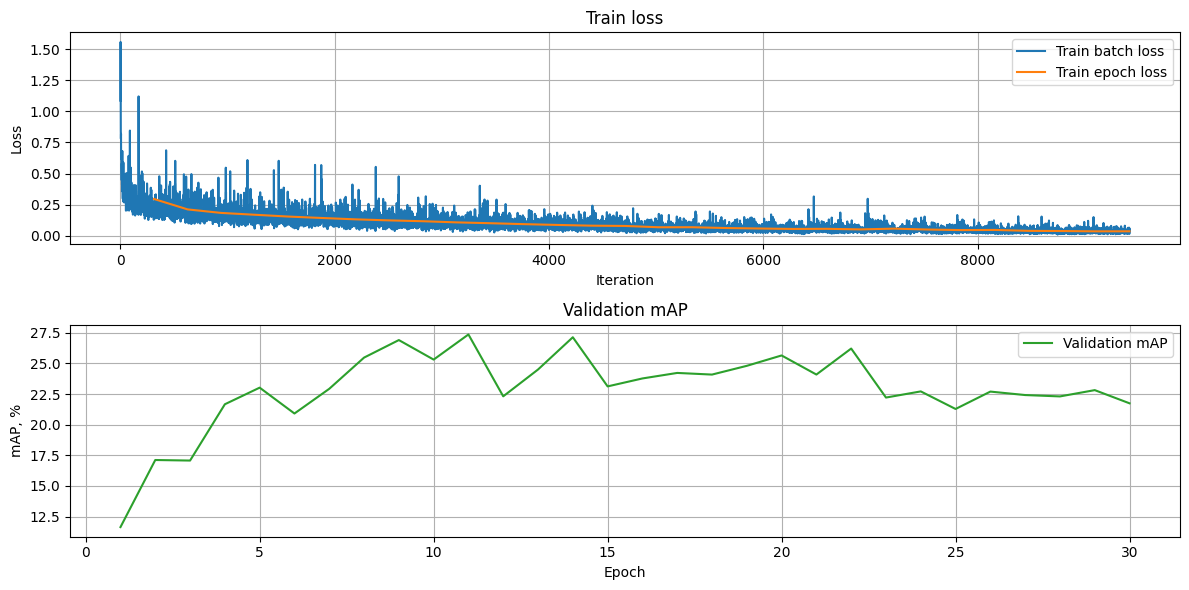

In [ ]:
runner.plot_loss()

In [ ]:
def denormalize_image(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    img = img_tensor.cpu() * std + mean
    img = img.clamp(0, 1)

    return img


@torch.no_grad()
def visualize_prediction(model, dataset, idx=0, score_threshold=0.2):
    model.eval()

    image, target = dataset[idx]

    image_batch = image.unsqueeze(0).to(device)

    outputs = model(image_batch)

    preds = _filter_predictions(
        outputs,
        score_threshold=score_threshold,
        nms_threshold=0.5,
        max_boxes_per_cls=50,
        return_type="torch"
    )[0]

    img_show = denormalize_image(image)
    img_show = img_show.permute(1, 2, 0).numpy()

    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    ax.imshow(img_show)

    # GT boxes — зелёные
    for box in target["boxes"]:
        x, y, w, h = box.tolist()

        rect = patches.Rectangle(
            (x, y),
            w,
            h,
            linewidth=2,
            edgecolor="lime",
            facecolor="none"
        )

        ax.add_patch(rect)

    # predicted boxes — красные
    for box, score in zip(preds["boxes"], preds["scores"]):
        x, y, w, h = box.tolist()

        rect = patches.Rectangle(
            (x, y),
            w,
            h,
            linewidth=2,
            edgecolor="red",
            facecolor="none"
        )

        ax.add_patch(rect)

        ax.text(
            x,
            y,
            f"{score:.2f}",
            color="white",
            fontsize=10,
            bbox=dict(facecolor="red", alpha=0.5)
        )

    ax.set_title("Green = GT, Red = prediction")
    ax.axis("off")
    plt.show()

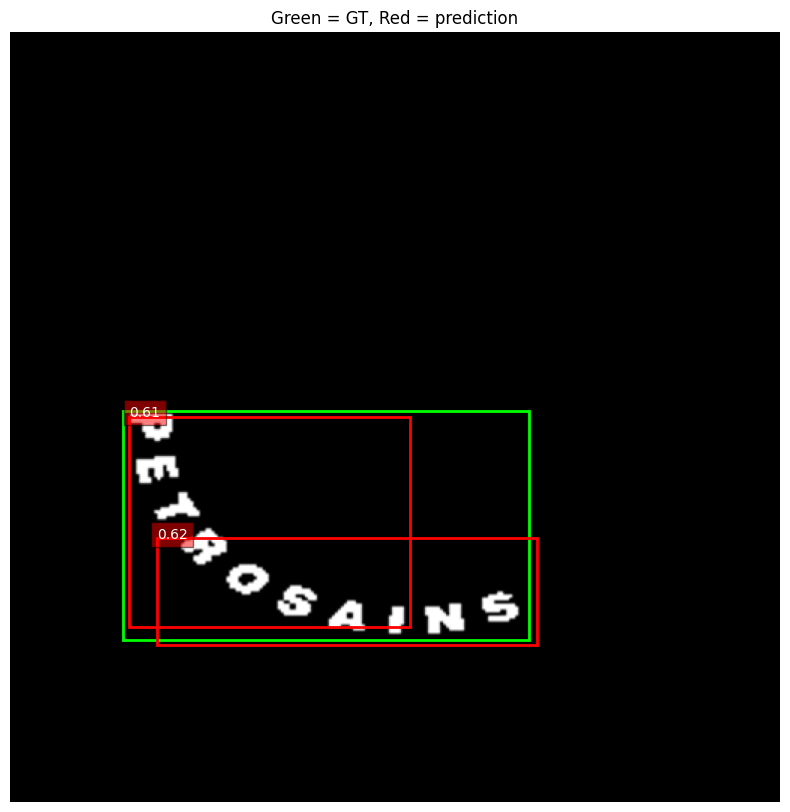

In [ ]:
visualize_prediction(model, val_dataset, idx=0, score_threshold=0.2)

###Многоуровневый якорный однопроходный детектор с Feature Pyramid Network

In [16]:
import torch.nn as nn
class Backbone(nn.Module):
    def __init__(self, model_name="efficientnet_b0", out_indices=(-1, -2, -3), unfreeze_last=3):
        super().__init__()
        # timm.list_models(pretrained=True)
        self.backbone = timm.create_model(model_name, pretrained=True, features_only=True, out_indices=out_indices)

        count_parameters = sum(1 for _ in self.backbone.parameters())
        # Выключаем градиенты у модели, чтобы упростить обучение
        # for i, param in enumerate(self.backbone.parameters()):
        #     if i <= count_parameters - unfreeze_last:
        #         param.requires_grad = False
        #     else:
        #         param.requires_grad = True


    def forward(self, x):
        return self.backbone(x)

In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Neck(nn.Module):
    """
    Feature Pyramid Network (FPN) neck.

    Принимает список feature maps из backbone (от нижнего разрешения к верхнему,
    т.е. [C2, C3, C4, C5] где C5 — самое маленькое пространственное разрешение)
    и возвращает список feature maps пирамиды [P2, P3, P4, P5] одинаковой размерности каналов.

    Параметры:
        in_channels_list (list[int]): список каналов входных признаков,
            например [256, 512, 1024, 2048] для ResNet.
        out_channels (int): количество каналов на выходе (по умолчанию 256).
        extra_conv (bool): если True, после каждого суммирования добавляется
            свёртка 3×3 с padding=1 (как в оригинальной статье).
    """
    def __init__(self, in_channels_list, out_channels=256, extra_conv=True):
        super().__init__()

        # латеральные свёртки 1×1 для приведения к единой размерности
        self.lateral_convs = nn.ModuleList()
        # сглаживающие свёртки 3×3 (или Identity)
        self.fpn_convs = nn.ModuleList()

        for in_ch in in_channels_list:
            lateral = nn.Conv2d(in_ch, out_channels, kernel_size=1)
            self.lateral_convs.append(lateral)

            if extra_conv:
                fpn_conv = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1)
            else:
                fpn_conv = nn.Identity()
            self.fpn_convs.append(fpn_conv)

        # Upsampling сделаем с помощью F.interpolate, поэтому обучаемых параметры не требуются.

    def forward(self, features):
        """ features: список тензоров [C2, C3, C4, C5] (от крупного к мелкому) """
        # применяем латеральные свёртки к каждому уровню
        laterals = [conv(feat) for conv, feat in zip(self.lateral_convs, features)]

        # идём от самого глубокого (мелкого) к самому крупному
        fpn_features = []
        # Начинаем с самого верхнего (мелкого) уровня
        prev = laterals[-1]
        fpn_features.append(prev)

        # Проходим по оставшимся (от предпоследнего до первого)
        for i in range(len(laterals) - 2, -1, -1):
            # Upsample с помощью nearest neighbor
            upsampled = F.interpolate(prev, size=laterals[i].shape[-2:], mode='nearest')
            # Суммируем с соответствующим латеральным признаком
            combined = laterals[i] + upsampled
            # Применяем сглаживающую свёртку 3×3
            combined = self.fpn_convs[i](combined)
            fpn_features.append(combined)
            prev = combined

        # fpn_features содержит [P5, P4, P3, P2] (от мелкого к крупному).
        # нужно его развернуть, чтобы сохранить порядок входных уровней [P2, P3, P4, P5].
        return fpn_features[::-1]

In [18]:
class Head(nn.Module):
    """
    Двухсоставная голова детекции без отдельного confidence score.

    Структура:
        neck -> conv -> conv (cls): [B, num_anchors * (num_classes + 1), H, W]
                      -> conv (reg): [B, num_anchors * 4, H, W]

    Класс "фон" автоматически добавляется как нулевой класс (индекс 0).
    """
    def __init__(self, in_channels, num_anchors, num_classes):
        """
        Args:
            in_channels (int): количество каналов на входе (от neck)
            num_anchors (int): количество якорей на точку
            num_classes (int): количество классов объектов (без фона)
        """
        super().__init__()
        self.num_classes = num_classes
        self.num_anchors = num_anchors

        # общая свёртка перед разделением на две головы
        self.conv = nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1)

        # голова классификации (включая фон)
        self.cls_head = nn.Conv2d(in_channels, num_anchors * self.num_classes, kernel_size=1)

        # голова регрессии
        # self.reg_head = nn.Conv2d(in_channels, num_anchors * 5, kernel_size=1)

        self.reg_head  = nn.Conv2d(in_channels, num_anchors * 4, 1)   # только bbox
        self.obj_head  = nn.Conv2d(in_channels, num_anchors, 1)       # confidence отдельно

    def forward(self, x):
        """
        Args:
            x (torch.Tensor): карта признаков от neck [B, C, H, W]

        Returns:
            cls_logits (torch.Tensor): логиты классов [B, num_anchors*(num_classes), H, W]
            bbox_preds (torch.Tensor): смещения bbox [B, num_anchors*4, H, W]
        """
        x = F.relu(self.conv(x))
        # cls_logits = self.cls_head(x)
        # bbox_preds = self.reg_head(x)

        # return cls_logits, bbox_preds

        return self.cls_head(x), self.reg_head(x), self.obj_head(x)

In [21]:
import math
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models.detection.rpn import AnchorGenerator


class Head(nn.Module):
    """
    Три независимые головы:
      - cls_head: логиты классов
      - reg_head: bbox offsets
      - obj_head: objectness (confidence) logits
    """
    def __init__(self, in_channels, num_anchors, num_classes):
        super().__init__()
        self.num_anchors = num_anchors
        self.num_classes = num_classes

        self.conv = nn.Conv2d(in_channels, in_channels, 3, padding=1)
        self.cls_head = nn.Conv2d(in_channels, num_anchors * num_classes, 1)
        self.reg_head = nn.Conv2d(in_channels, num_anchors * 4, 1)
        self.obj_head = nn.Conv2d(in_channels, num_anchors, 1)

    def forward(self, x):
        x = F.relu(self.conv(x))
        cls_logits = self.cls_head(x)
        bbox_preds = self.reg_head(x)
        obj_logits = self.obj_head(x)
        return cls_logits, bbox_preds, obj_logits


class Detector(nn.Module):
    def __init__(self,
                 backbone_model_name="efficientnet_b0",
                 neck_n_channels=256,
                 num_classes=1,
                 anchor_sizes=(32, 64, 128),
                 anchor_ratios=(0.5, 1.0, 2.0),
                 input_size=(640, 640),
                 backbone_out_indices=(-3, -2, -1)):
        super().__init__()
        self.input_size = input_size
        self.num_classes = num_classes

        self.backbone = Backbone(backbone_model_name, out_indices=backbone_out_indices)
        in_channels_list = self.backbone.backbone.feature_info.channels()

        self.neck = Neck(in_channels_list, out_channels=neck_n_channels)

        num_anchors_per_cell = len(anchor_sizes) * len(anchor_ratios)
        self.head = Head(
            in_channels=neck_n_channels,
            num_anchors=num_anchors_per_cell,
            num_classes=num_classes
        )

        # ── Prior-bias для objectness (RetinaNet-style) ──
        prior_prob = 0.01
        bias_value = -math.log((1 - prior_prob) / prior_prob)
        nn.init.constant_(self.head.obj_head.bias, bias_value)
        nn.init.normal_(self.head.obj_head.weight, std=0.01)

        nn.init.normal_(self.head.reg_head.weight, std=0.01)
        nn.init.constant_(self.head.reg_head.bias, 0.0)

        nn.init.normal_(self.head.cls_head.weight, std=0.01)
        nn.init.constant_(self.head.cls_head.bias, 0.0)

        # ── Anchors ──
        num_levels = len(in_channels_list)
        reductions = self.backbone.backbone.feature_info.reduction()
        multi_level_sizes = tuple([anchor_sizes] * num_levels)
        multi_level_ratios = tuple([anchor_ratios] * num_levels)

        anchor_generator = AnchorGenerator(
            sizes=multi_level_sizes,
            aspect_ratios=multi_level_ratios
        )

        grid_sizes = [[input_size[0] // r, input_size[1] // r] for r in reductions]
        strides = [[r, r] for r in reductions]

        anchors = anchor_generator.grid_anchors(grid_sizes, strides=strides)
        anchors = torch.cat(anchors, dim=0).unsqueeze(0)   # [1, Total_A, 4]
        anchor_centers = (anchors[..., :2] + anchors[..., 2:]) / 2
        anchor_wh = anchors[..., 2:] - anchors[..., :2]

        self.register_buffer("anchors", anchors)
        self.register_buffer("anchor_centers", anchor_centers)
        self.register_buffer("anchor_sizes", anchor_wh)

    def forward(self, x):
        features = self.backbone(x)
        neck_features = self.neck(features)

        N = x.shape[0]
        final_cls = []
        final_bbox = []
        final_conf_log = []

        for level_feat in neck_features:
            cls_l, bbox_p, obj_l = self.head(level_feat)   # ← 3 значения

            # cls_l: [N, num_anchors * num_classes, H, W] -> [N, A, num_classes]
            cls_l = cls_l.permute(0, 2, 3, 1).contiguous()
            cls_l = cls_l.view(N, -1, self.num_classes)

            # bbox_p: [N, num_anchors * 4, H, W] -> [N, A, 4]
            bbox_p = bbox_p.permute(0, 2, 3, 1).contiguous()
            bbox_p = bbox_p.view(N, -1, 4)

            # obj_l: [N, num_anchors, H, W] -> [N, A]
            obj_l = obj_l.permute(0, 2, 3, 1).contiguous()
            obj_l = obj_l.view(N, -1)

            final_cls.append(cls_l)
            final_bbox.append(bbox_p)
            final_conf_log.append(obj_l)

        cls_logits        = torch.cat(final_cls,      dim=1)  # [N, Total_A, num_classes]
        bbox_offsets      = torch.cat(final_bbox,     dim=1)  # [N, Total_A, 4]
        confidence_logits = torch.cat(final_conf_log, dim=1)  # [N, Total_A]

        if self.training:
            return bbox_offsets, confidence_logits, cls_logits

        bboxes = self.decode_bboxes(bbox_offsets)
        confidence = torch.sigmoid(confidence_logits)

        # для single-class задачи cls_probs не влияет — можно оставить единицы,
        # НО тогда обязательно поднимите score_threshold до 0.1+
        cls_probs = torch.ones_like(cls_logits)

        return bboxes, confidence, cls_probs

    def decode_bboxes(self, bbox_offsets):
        bbox_offsets = torch.clamp(bbox_offsets, -10, 10)

        tx = bbox_offsets[..., 0]
        ty = bbox_offsets[..., 1]
        tw = bbox_offsets[..., 2]
        th = bbox_offsets[..., 3]

        center_x = self.anchor_centers[..., 0] + tx * self.anchor_sizes[..., 0]
        center_y = self.anchor_centers[..., 1] + ty * self.anchor_sizes[..., 1]

        w = torch.exp(tw) * self.anchor_sizes[..., 0]
        h = torch.exp(th) * self.anchor_sizes[..., 1]

        x_min = center_x - w / 2
        y_min = center_y - h / 2

        return torch.stack([x_min, y_min, w, h], dim=-1)

In [22]:
def assign_target(
    anchors,
    gt_boxes,
    gt_labels,
    num_classes,
    pos_th=0.4,
    neg_th=0.2
):
    """
    anchors:   [num_anchors, 4] — xyxy
    gt_boxes:  [num_gt, 4]     — xywh (пиксели)
    gt_labels: [num_gt]        — классы начиная с 0
    """
    num_anchors = anchors.shape[0]

    target_objectness = torch.zeros(num_anchors,       device=anchors.device)
    target_offsets    = torch.zeros((num_anchors, 4),  device=anchors.device)
    target_cls        = torch.zeros((num_anchors, num_classes), device=anchors.device)

    if gt_boxes.numel() == 0:
        return target_offsets, target_objectness, target_cls

    # xywh -> xyxy
    gt_xyxy        = gt_boxes.clone()
    gt_xyxy[:, 2:] = gt_xyxy[:, :2] + gt_xyxy[:, 2:]

    ious                    = box_iou(anchors, gt_xyxy)   # [num_anchors, num_gt]
    best_iou, best_gt_idx   = ious.max(dim=1)

    # Игнорируемые якоря
    ignore_mask                    = (best_iou >= neg_th) & (best_iou < pos_th)
    target_objectness[ignore_mask] = -1

    # Положительные якоря
    pos_mask    = best_iou >= pos_th
    pos_indices = pos_mask.nonzero(as_tuple=True)[0]

    for pos in pos_indices:
        gt_idx     = best_gt_idx[pos]
        gt_box     = gt_xyxy[gt_idx]
        anchor_box = anchors[pos]

        target_offsets[pos]    = get_target_offset(anchor_box, gt_box)
        target_objectness[pos] = 1

        target_cls[pos, 0] = 1

    # Гарантируем что каждый GT получит хотя бы один якорь
    for gt_idx in range(gt_xyxy.shape[0]):
        already_assigned = ((target_objectness == 1) & (best_gt_idx == gt_idx)).any()

        if not already_assigned:
            best_anchor_idx = torch.argmax(ious[:, gt_idx])

            target_offsets[best_anchor_idx]    = get_target_offset(
                anchors[best_anchor_idx], gt_xyxy[gt_idx]
            )
            target_objectness[best_anchor_idx] = 1

            target_cls[best_anchor_idx, 0] = 1

    return target_offsets, target_objectness, target_cls

In [23]:
class ComputeLoss:
    def __init__(
        self,
        weight_bbox=5.0,
        weight_obj=1.0,
        weight_cls=0.0,
        obj_pos_weight=10.0,
        neg_pos_ratio=10,
        min_neg=100
    ):
        self.bbox_loss = nn.SmoothL1Loss()
        self.weight_bbox = weight_bbox
        self.weight_obj = weight_obj
        self.weight_cls = weight_cls
        self.obj_pos_weight = obj_pos_weight
        self.neg_pos_ratio = neg_pos_ratio
        self.min_neg = min_neg

    def __call__(self, predicts, targets):
        pred_offsets, pred_obj_logits, pred_cls_logits = predicts
        target_offsets, target_obj, target_cls = targets

        pos_mask = target_obj == 1
        neg_mask = target_obj == 0

        obj_targets = target_obj.clamp(0, 1).float()

        raw_obj_loss = F.binary_cross_entropy_with_logits(
            pred_obj_logits,
            obj_targets,
            reduction="none"
        )

        pos_loss = raw_obj_loss[pos_mask]
        neg_loss = raw_obj_loss[neg_mask]

        num_pos = int(pos_mask.sum().item())

        if neg_loss.numel() > 0:
            num_neg_keep = min(
                neg_loss.numel(),
                max(self.min_neg, self.neg_pos_ratio * max(num_pos, 1))
            )

            neg_loss = torch.topk(
                neg_loss,
                k=num_neg_keep,
                largest=True
            ).values
        else:
            num_neg_keep = 0

        denom = max(pos_loss.numel() + num_neg_keep, 1)

        loss_obj = (
            pos_loss.sum() + neg_loss.sum()
        ) / denom

        if pos_mask.sum() > 0:
            loss_bbox = self.bbox_loss(
                pred_offsets[pos_mask],
                target_offsets[pos_mask]
            )
        else:
            loss_bbox = torch.tensor(0.0, device=pred_offsets.device)

        if self.weight_cls > 0 and pos_mask.sum() > 0:
            loss_cls = F.binary_cross_entropy_with_logits(
                pred_cls_logits[pos_mask],
                target_cls[pos_mask]
            )
        else:
            loss_cls = torch.tensor(0.0, device=pred_offsets.device)

        total_loss = (
            self.weight_bbox * loss_bbox
            + self.weight_obj * loss_obj
            + self.weight_cls * loss_cls
        )

        return total_loss

In [24]:
def _filter_predictions(
    predictions,
    score_threshold  = 0.1,
    nms_threshold    = 0.5,
    max_boxes_per_cls = 50,
    return_type      = "list"
):
    """
    predictions:
        bboxes:      [B, N, 4]  xywh
        confidences: [B, N]
        cls_probs:   [B, N, C]  после sigmoid
    """
    bboxes, confidences, cls_probs = predictions

    all_final_scores = confidences[:, :, None] * cls_probs  # [B, N, C]

    num_classes       = cls_probs.shape[-1]
    final_predictions = []

    for boxes, final_scores in zip(bboxes, all_final_scores):
        preds = {"boxes": [], "labels": [], "scores": []}

        for cls in range(num_classes):
            cls_scores = final_scores[:, cls]
            keep_ixs   = cls_scores > score_threshold

            if keep_ixs.sum() == 0:
                continue

            cls_boxes  = boxes[keep_ixs]
            cls_scores = cls_scores[keep_ixs]

            # Оставляем только топ max_boxes_per_cls
            if len(cls_boxes) > max_boxes_per_cls:
                pos        = torch.argsort(cls_scores, descending=True)
                cls_boxes  = cls_boxes[pos[:max_boxes_per_cls]]
                cls_scores = cls_scores[pos[:max_boxes_per_cls]]

            # xywh -> xyxy для NMS
            boxes_xyxy        = cls_boxes.clone()
            boxes_xyxy[:, 2:] = boxes_xyxy[:, :2] + boxes_xyxy[:, 2:]

            pred_ixs = nms(boxes_xyxy, cls_scores, nms_threshold)

            for ix in pred_ixs:
                preds["boxes"].append(cls_boxes[ix].detach().cpu().tolist())
                preds["labels"].append(cls)
                preds["scores"].append(cls_scores[ix].detach().cpu().item())

        if return_type == "torch":
            if len(preds["boxes"]) == 0:
                preds["boxes"]  = torch.zeros((0, 4), dtype=torch.float32)
                preds["labels"] = torch.zeros((0,),   dtype=torch.long)
                preds["scores"] = torch.zeros((0,),   dtype=torch.float32)
            else:
                preds["boxes"]  = torch.tensor(preds["boxes"],  dtype=torch.float32)
                preds["labels"] = torch.tensor(preds["labels"], dtype=torch.long)
                preds["scores"] = torch.tensor(preds["scores"], dtype=torch.float32)
        elif return_type != "list":
            raise ValueError("return_type должен быть 'torch' или 'list'")

        final_predictions.append(preds)

    return final_predictions

Device: cuda


Training:   0%|          | 0/50 [00:00<?, ?it/s]

Train epoch:   0%|          | 0/314 [00:00<?, ?it/s]

Validation:   0%|          | 0/75 [00:00<?, ?it/s]

mAP: 0.0000, mAP50: 0.0000, mAP75: 0.0000
Checkpoint saved: /content/drive/MyDrive/МФТИ ML/Семестр 1/Итоговое задание/new_detect2/epoch_001.pt
Last checkpoint updated: /content/drive/MyDrive/МФТИ ML/Семестр 1/Итоговое задание/new_detect2/last.pt
Best checkpoint updated: /content/drive/MyDrive/МФТИ ML/Семестр 1/Итоговое задание/new_detect2/best.pt


...

Validation:   0%|          | 0/75 [00:00<?, ?it/s]

mAP: 0.0000, mAP50: 0.0000, mAP75: 0.0000
Checkpoint saved: /content/drive/MyDrive/МФТИ ML/Семестр 1/Итоговое задание/new_detect2/epoch_049.pt
Last checkpoint updated: /content/drive/MyDrive/МФТИ ML/Семестр 1/Итоговое задание/new_detect2/last.pt


Train epoch:   0%|          | 0/314 [00:00<?, ?it/s]

Validation:   0%|          | 0/75 [00:00<?, ?it/s]

mAP: 0.0000, mAP50: 0.0000, mAP75: 0.0000
Checkpoint saved: /content/drive/MyDrive/МФТИ ML/Семестр 1/Итоговое задание/new_detect2/epoch_050.pt
Last checkpoint updated: /content/drive/MyDrive/МФТИ ML/Семестр 1/Итоговое задание/new_detect2/last.pt


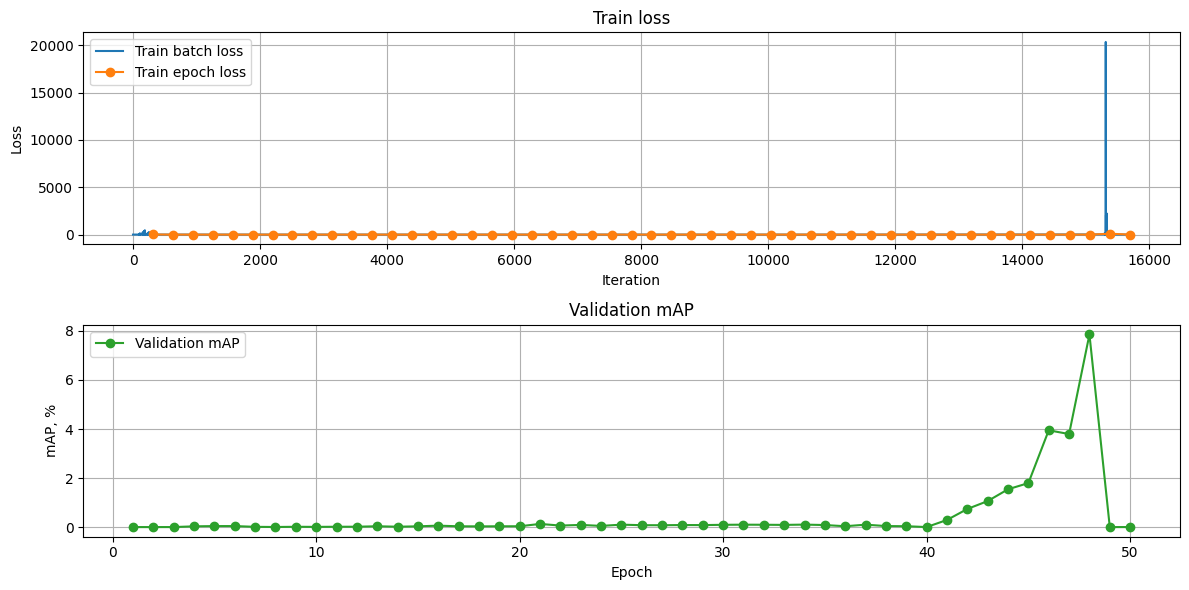

In [34]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

model = Detector(
    backbone_model_name = "efficientnet_b0",
    neck_n_channels     = 256,
    num_classes         = 1,
    # anchor_sizes        = (16, 32, 64, 128, 256, 512),
    # anchor_ratios       = (0.25, 0.5, 1.0, 2.0, 4.0),
    anchor_sizes = (8, 16, 32, 64),
    anchor_ratios = (0.1, 0.2, 0.5, 1.0, 2.0),
    input_size          = (512, 512),
    backbone_out_indices=(-3, -2, -1)
).to(device)


compute_loss = ComputeLoss(
    weight_bbox=5.0,
    weight_obj=1.0,
    weight_cls=0.0,
    neg_pos_ratio=10,
    min_neg=100
)

optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr           = 1e-3,
    weight_decay = 1e-4
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max = 30,
    eta_min = 1e-5
)


checkpoint_dir = "/content/drive/MyDrive/МФТИ ML/Семестр 1/Итоговое задание/new_detect2/"

runner = Runner(
    model=model,
    compute_loss=compute_loss,
    optimizer=optimizer,
    train_dataloader=train_dataloader,
    assign_target_method=assign_target,
    assign_target_kwargs={
        "pos_th": 0.4,
        "neg_th": 0.2
    },
    device=device,
    scheduler=scheduler,
    val_dataloader=val_dataloader,
    val_every=1,
    score_threshold=0.001,
    nms_threshold=0.5,
    max_boxes_per_cls=50,
    checkpoint_dir=checkpoint_dir
)

runner.train(num_epochs=50)
runner.plot_loss()

In [31]:
def denormalize_image(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

    img = img_tensor.cpu() * std + mean
    img = img.clamp(0, 1)

    return img


@torch.no_grad()
def visualize_prediction(model, dataset, idx=0, score_threshold=0.2):
    model.eval()

    image, target = dataset[idx]

    image_batch = image.unsqueeze(0).to(device)

    outputs = model(image_batch)

    preds = _filter_predictions(
        outputs,
        score_threshold=score_threshold,
        nms_threshold=0.5,
        max_boxes_per_cls=50,
        return_type="torch"
    )[0]

    img_show = denormalize_image(image)
    img_show = img_show.permute(1, 2, 0).numpy()

    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    ax.imshow(img_show)

    # GT boxes — зелёные
    for box in target["boxes"]:
        x, y, w, h = box.tolist()

        rect = patches.Rectangle(
            (x, y),
            w,
            h,
            linewidth=2,
            edgecolor="lime",
            facecolor="none"
        )

        ax.add_patch(rect)

    # predicted boxes — красные
    for box, score in zip(preds["boxes"], preds["scores"]):
        x, y, w, h = box.tolist()

        rect = patches.Rectangle(
            (x, y),
            w,
            h,
            linewidth=2,
            edgecolor="red",
            facecolor="none"
        )

        ax.add_patch(rect)

        ax.text(
            x,
            y,
            f"{score:.2f}",
            color="white",
            fontsize=10,
            bbox=dict(facecolor="red", alpha=0.5)
        )

    ax.set_title("Green = GT, Red = prediction")
    ax.axis("off")
    plt.show()

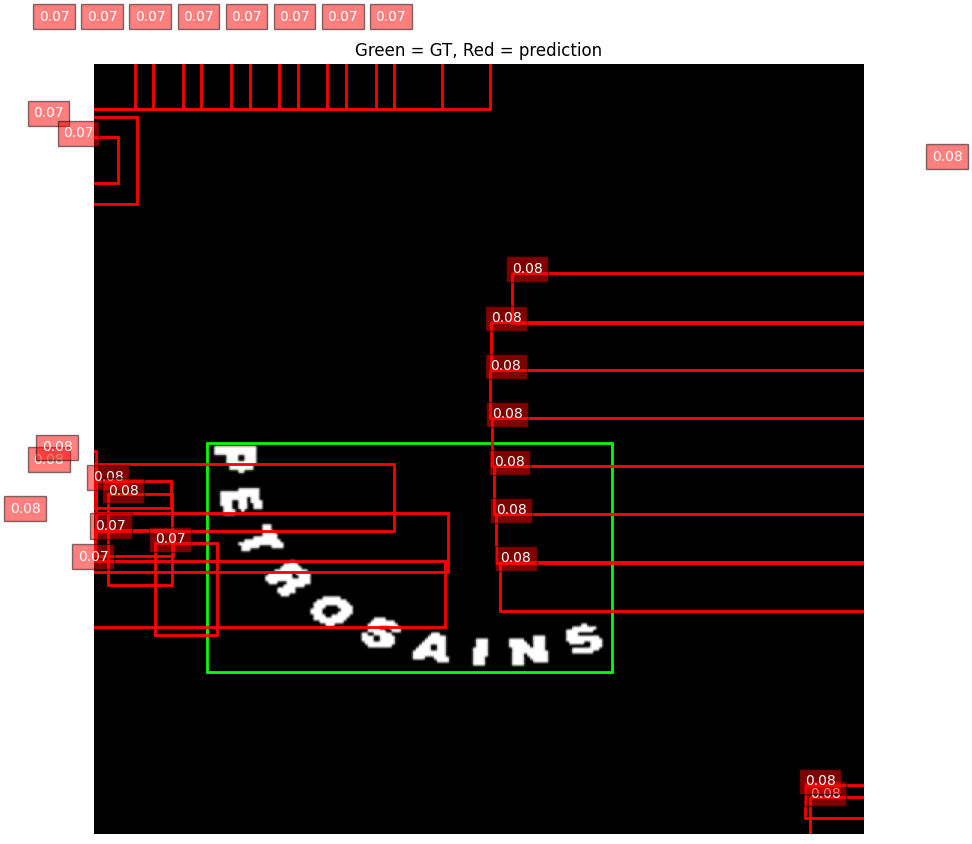

In [35]:
visualize_prediction(model, val_dataset, idx=0, score_threshold=0)

In [29]:
missing = 0

for img_path in train_dataset.image_paths[:100]:
    label_path = train_dataset.labels_dir / f"{img_path.stem}.txt"

    if not label_path.exists():
        missing += 1
        print("Нет label:", img_path.name, "->", label_path)

print("missing:", missing)

missing: 0


In [30]:
widths = []
heights = []

for i in range(min(len(train_dataset), 500)):
    _, target = train_dataset[i]

    if len(target["boxes"]) == 0:
        continue

    boxes = target["boxes"]
    widths.extend(boxes[:, 2].tolist())
    heights.extend(boxes[:, 3].tolist())

print("Width percentiles:", np.percentile(widths, [1, 5, 25, 50, 75, 95]))
print("Height percentiles:", np.percentile(heights, [1, 5, 25, 50, 75, 95]))

Width percentiles: [ 10.63381788  16.21680231  30.79999924  51.11808395  88.74666595
 196.52456512]
Height percentiles: [  8.53333378  11.37777805  20.2772274   31.74399948  55.29600143
 115.48032761]
